# lr and hr same size

In [1]:
# import os
# import shutil

# # Local paths
# data_path = r"D:\Face_Detection\archive\surveillance_cameras_all"
# output_path = r"D:\Face_Detection\prepared_dataset"

# # Create split folders
# for split in ['train', 'val', 'test']:
#     os.makedirs(os.path.join(output_path, split), exist_ok=True)

# # List all files
# all_files = os.listdir(data_path)

# # Extract unique person IDs
# person_ids = sorted({f[:3] for f in all_files})  # first 3 characters

# # Define splits
# train_ids = person_ids[:90]
# val_ids = person_ids[90:110]
# test_ids = person_ids[110:]

# # Function to copy images based on person_id
# def copy_split(person_list, split_name):
#     for f in all_files:
#         if f[:3] in person_list:
#             split_folder = os.path.join(output_path, split_name)
#             os.makedirs(split_folder, exist_ok=True)
#             shutil.copy(os.path.join(data_path, f), split_folder)

# # Copy images
# copy_split(train_ids, 'train')
# copy_split(val_ids, 'val')
# copy_split(test_ids, 'test')

# print("Dataset split completed!")

Dataset split completed!


In [50]:
# import os
# from PIL import Image
# import numpy as np
# import cv2
# import random

# split_folders = ['train', 'val', 'test']
# input_path = r"D:\Face_Detection\prepared_dataset"
# output_path = r"D:\Face_Detection\prepared_dataset_sr_light"  # LR-HR pairs

# # Make folders
# for split in split_folders:
#     os.makedirs(os.path.join(output_path, split, 'HR'), exist_ok=True)
#     os.makedirs(os.path.join(output_path, split, 'LR'), exist_ok=True)

# # Function to assign strength based on filename
# def get_strength_from_filename(filename):
#     # Check for cam8 first (strongest degradation)
#     if '_cam8.jpg' in filename:
#         return 1.5  # very strong worsening for cam8
#     elif filename.endswith('_1.jpg'):
#         return 0.2  # minimal worsening
#     elif filename.endswith('_2.jpg'):
#         return 0.5  # medium worsening
#     elif filename.endswith('_3.jpg'):
#         return 0.9  # stronger worsening
#     else:
#         return random.uniform(0.15, 0.65)  # default random if pattern not matched

# # Scanline shift effect (like analog TV/CCTV glitches)
# def add_scanline_shift(img, strength):
#     """
#     Shifts horizontal rows randomly left/right with brightness changes
#     More frequent and evenly distributed
#     """
#     if strength < 0.05:  # lower threshold so it applies more often
#         return img
    
#     h, w = img.shape[:2]
#     result = img.copy()
    
#     # Number of glitch bands based on strength (more bands now)
#     num_bands = int(2 + strength * 4)  # 4-10 bands
    
#     # Calculate even spacing
#     spacing = h // (num_bands + 1)  # divide image height evenly
    
#     for i in range(num_bands):
#         # Evenly spaced position with small random offset
#         base_position = spacing * (i + 1)
#         random_offset = random.randint(-spacing // 3, spacing // 3)
#         start_row = max(0, min(base_position + random_offset, h - 6))
        
#         band_height = random.randint(6, 24)  # 4-10 pixel high bands
#         end_row = min(start_row + band_height, h)
        
#         # Random horizontal shift
#         max_shift = int(1 + strength * 2)  # up to 4 pixels
#         shift = random.randint(-max_shift, max_shift)
        
#         # Skip if shift is too small (to avoid processing bands that don't shift)
#         if abs(shift) < 1:
#             continue
        
#         # Extract the band
#         band = result[start_row:end_row, :].copy()
        
#         # Shift the band horizontally
#         if shift > 0:  # shift right
#             band[:, shift:] = band[:, :-shift]
#             band[:, :shift] = band[:, shift:shift+1]  # fill with edge pixels
#         elif shift < 0:  # shift left
#             band[:, :shift] = band[:, -shift:]
#             band[:, shift:shift+1] = band[:, shift-1:shift]  # fill with edge pixels
        
#         # Add brightness/darkness variation
#         brightness_change = random.uniform(-12 * strength, 12 * strength)
#         band = np.clip(band.astype(np.float32) + brightness_change, 0, 255).astype(np.uint8)
        
#         # Put the modified band back
#         result[start_row:end_row, :] = band
    
#     return result

# # Improved degradation function with subtle color noise
# def degrade_image_conditional(img, strength):
#     img = np.array(img).astype(np.float32)

#     # 1. Downscale and upscale (bicubic for smoother result)
#     downscale_factor = 2 + (1.75 * strength)  # 2.15 to 3.5x
#     h, w = img.shape[:2]
#     new_h, new_w = max(1, int(h / downscale_factor)), max(1, int(w / downscale_factor))
    
#     lr = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
#     lr = cv2.resize(lr, (w, h), interpolation=cv2.INTER_CUBIC)

#     # 2. Gaussian blur (simulates camera blur)
#     kernel_size = 1 + int(2 * strength)
#     if kernel_size % 2 == 0:
#         kernel_size += 1
#     lr = cv2.GaussianBlur(lr, (kernel_size, kernel_size), 0)

#     # 3. Add subtle Gaussian noise (grayscale-like)
#     sigma = 4 * strength
#     noise = np.random.normal(0, sigma, lr.shape)
#     lr = lr + noise
    
#     # 4. Add "rainbow pixel" noise (the original method, but gentler)
#     # This creates the color artifacts by clipping in uint8 space
#     lr_uint8 = np.clip(lr, 0, 255).astype(np.uint8)
    
#     rainbow_strength = 0.4 * strength  # control the intensity
#     rainbow_noise = np.random.normal(0, rainbow_strength, lr.shape).astype(np.uint8)
#     lr = cv2.add(lr_uint8, rainbow_noise)  # cv2.add causes the wraparound effect
    
#     # 5. Add scanline shift (analog TV/CCTV glitch) - now more prominent
#     lr = add_scanline_shift(lr, strength * 0.8)  # increased from 0.6 to 0.8
    
#     # 6. JPEG compression
#     jpeg_quality = int(85 - (40* strength))  # 75 to 60 quality
#     encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), jpeg_quality]
#     _, encimg = cv2.imencode('.jpg', lr, encode_param)
#     lr = cv2.imdecode(encimg, cv2.IMREAD_COLOR)

#     return lr

# # Process each split
# for split in split_folders:
#     input_split = os.path.join(input_path, split)
#     hr_folder = os.path.join(output_path, split, 'HR')
#     lr_folder = os.path.join(output_path, split, 'LR')

#     count = 0
#     for f in os.listdir(input_split):
#         # Open HR image
#         hr_img = Image.open(os.path.join(input_split, f)).convert('RGB')
#         hr_img.save(os.path.join(hr_folder, f))

#         # Determine strength based on filename
#         strength = get_strength_from_filename(f)

#         # Generate LR image with conditional degradation
#         lr_img = degrade_image_conditional(hr_img, strength)
#         lr_img = Image.fromarray(lr_img)
#         lr_img.save(os.path.join(lr_folder, f))
        
#         count += 1
#         if count % 100 == 0:
#             print(f"{split}: Processed {count} images...")

# print("LR-HR dataset prepared with improved degradation!")

train: Processed 100 images...
train: Processed 200 images...
train: Processed 300 images...
train: Processed 400 images...
train: Processed 500 images...
train: Processed 600 images...
train: Processed 700 images...
train: Processed 800 images...
train: Processed 900 images...
train: Processed 1000 images...
train: Processed 1100 images...
train: Processed 1200 images...
train: Processed 1300 images...
train: Processed 1400 images...
train: Processed 1500 images...
train: Processed 1600 images...
train: Processed 1700 images...
train: Processed 1800 images...
train: Processed 1900 images...
val: Processed 100 images...
val: Processed 200 images...
val: Processed 300 images...
val: Processed 400 images...
test: Processed 100 images...
test: Processed 200 images...
test: Processed 300 images...
test: Processed 400 images...
LR-HR dataset prepared with improved degradation!



=== TRAIN ===


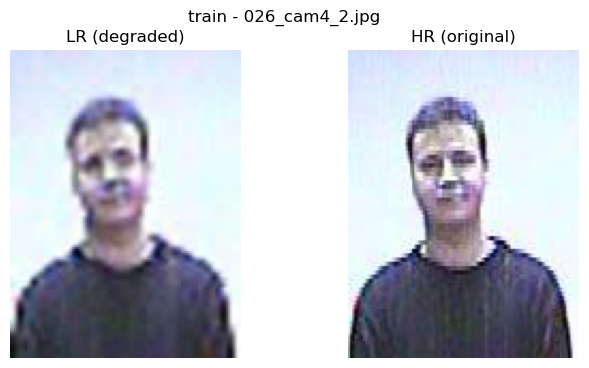

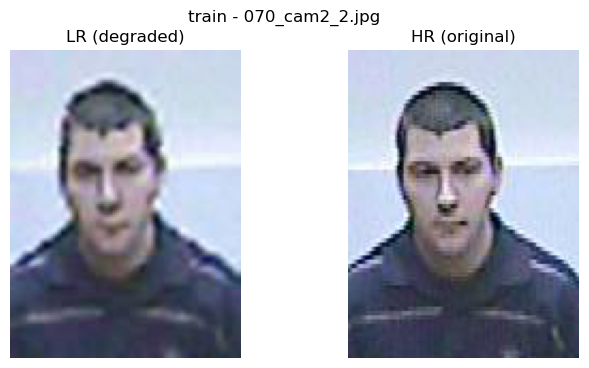

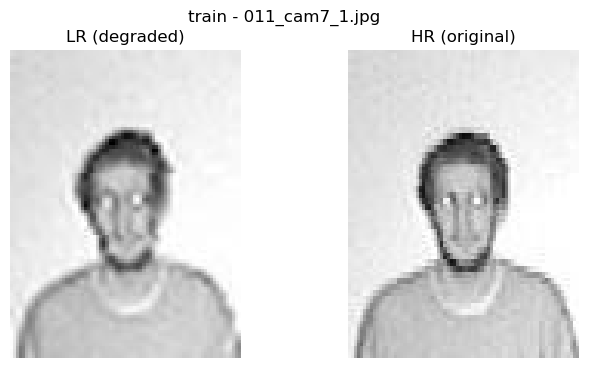

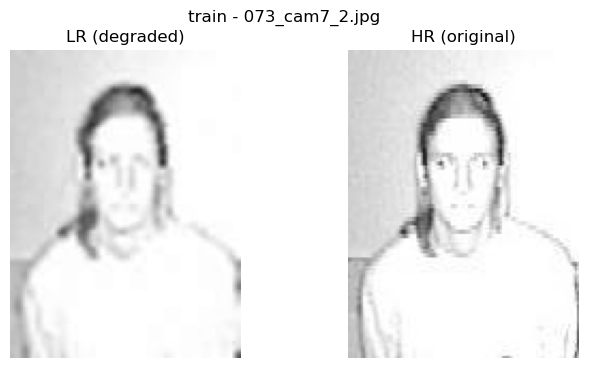

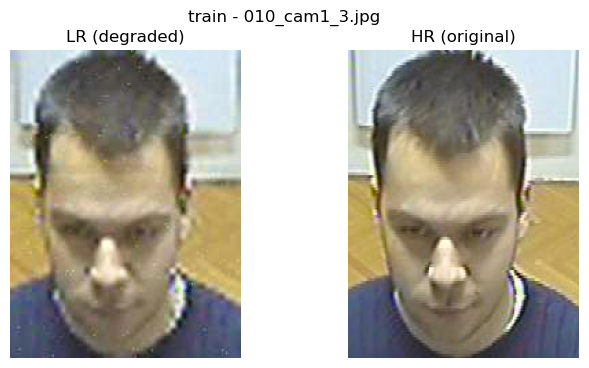

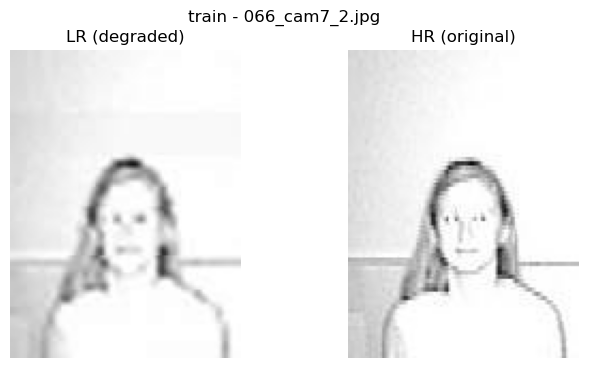

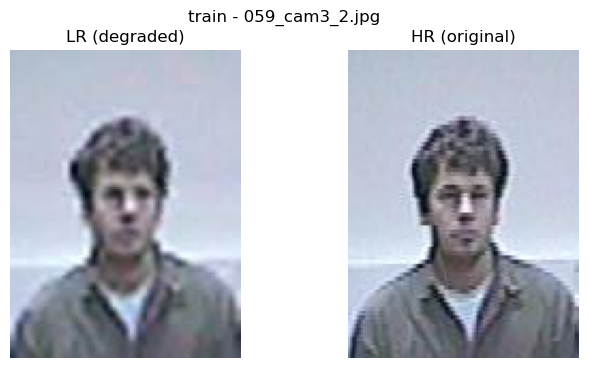

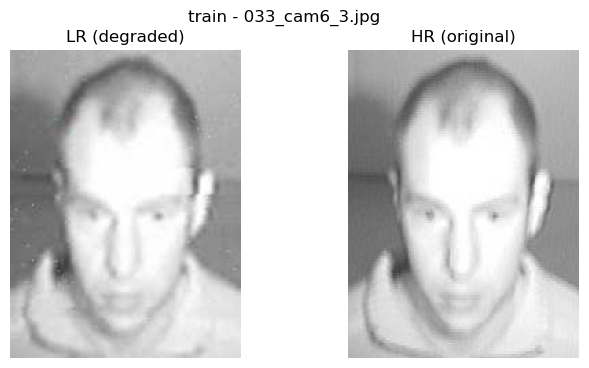

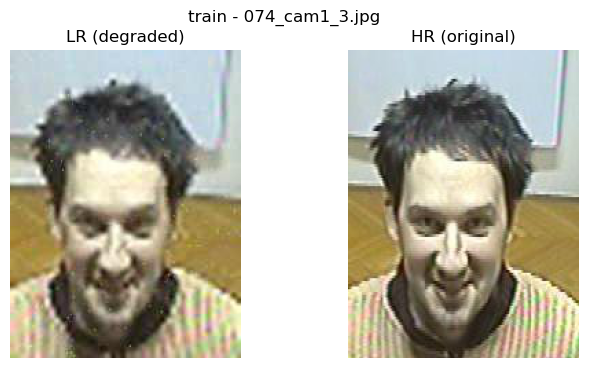

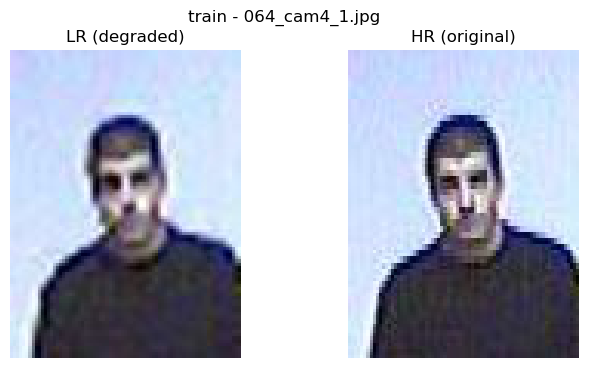

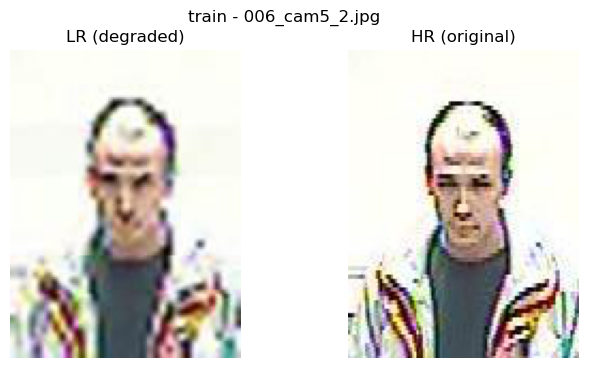

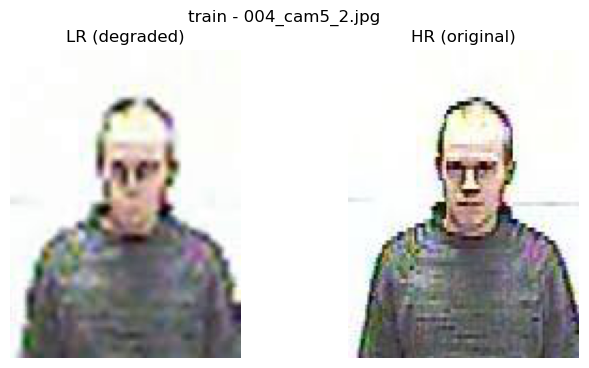


=== VAL ===


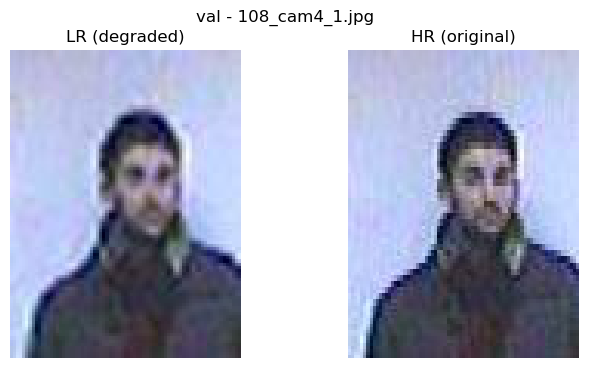

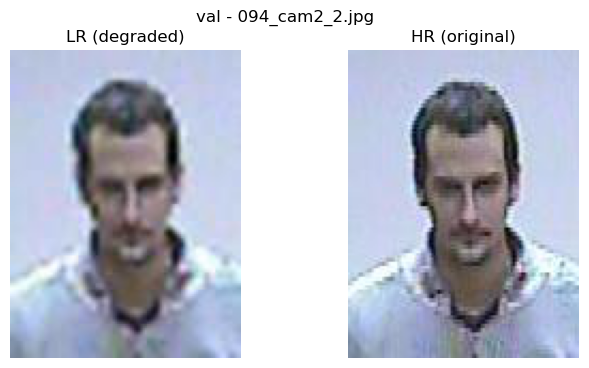

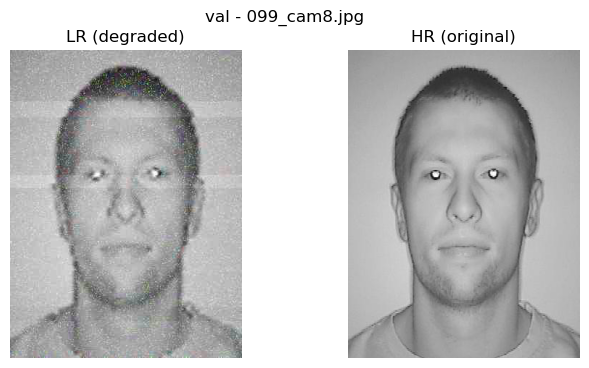

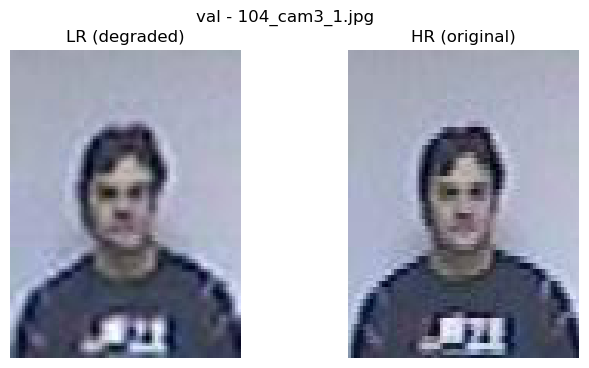

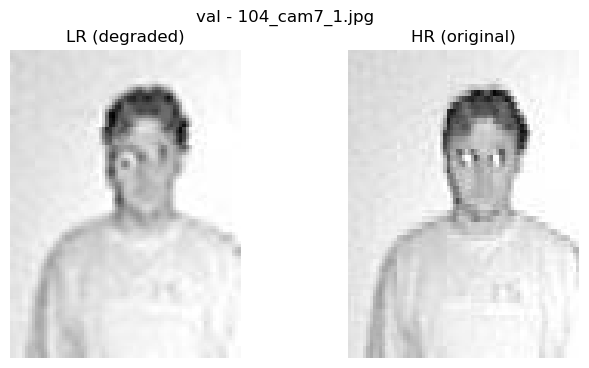

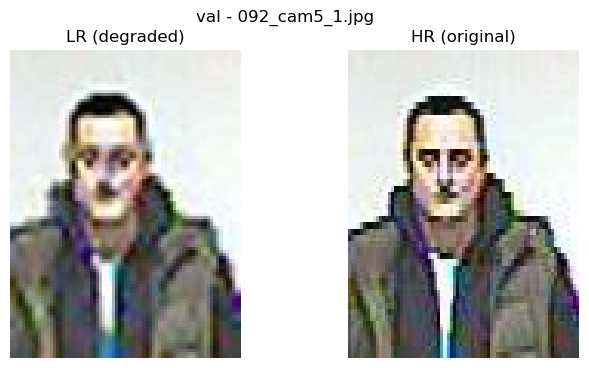

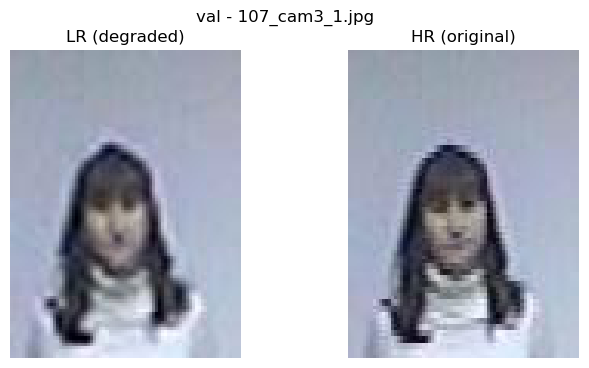

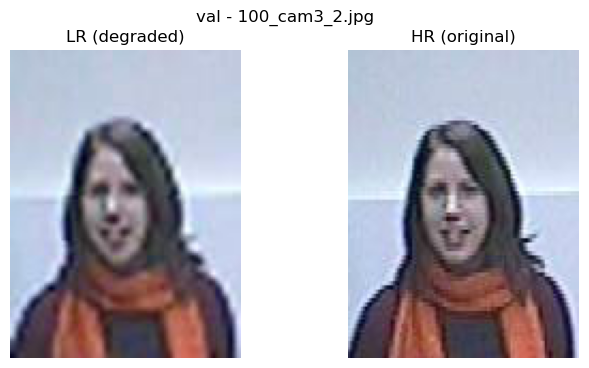

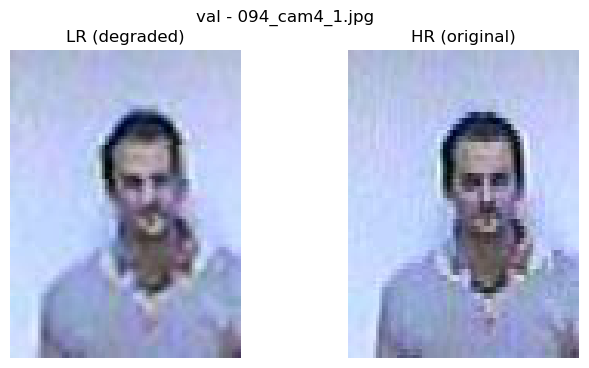

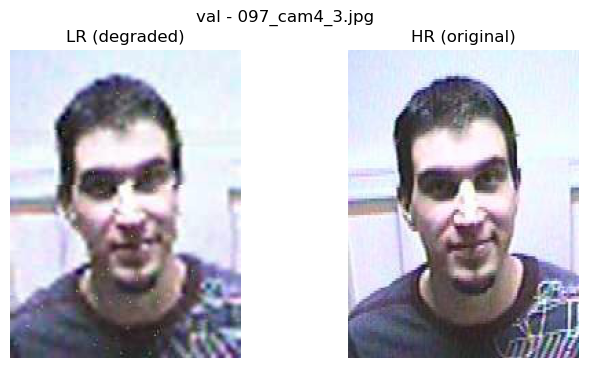

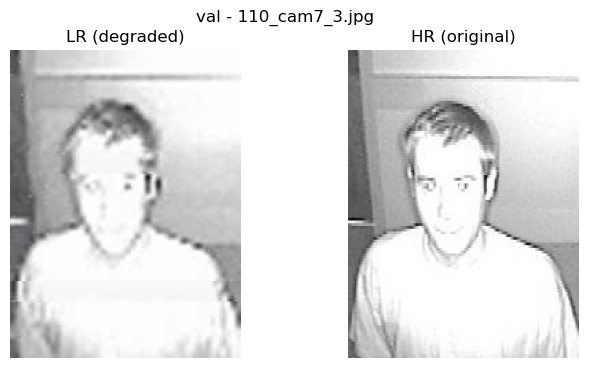

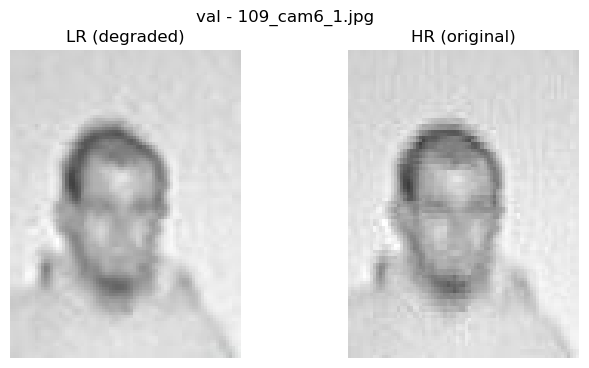


=== TEST ===


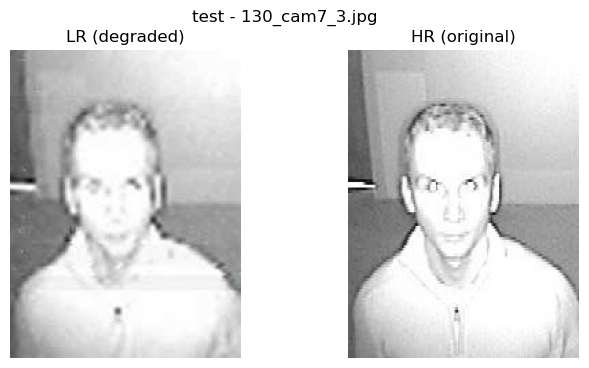

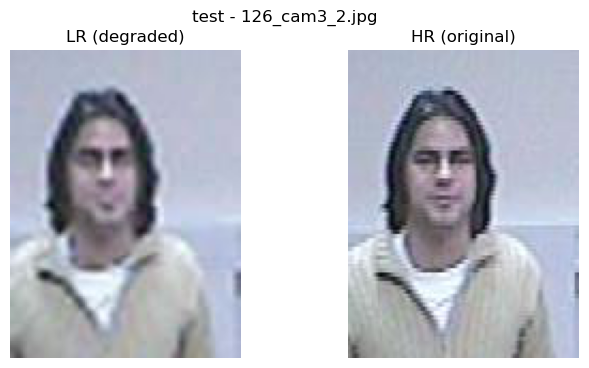

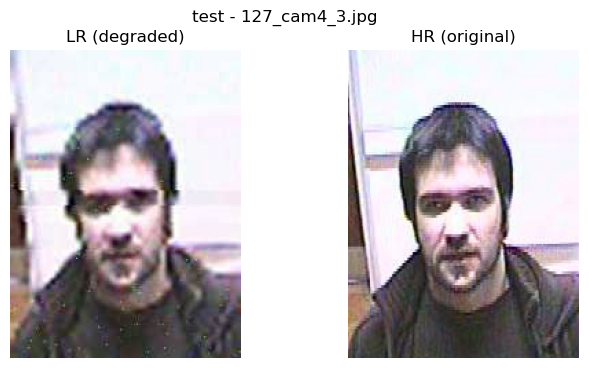

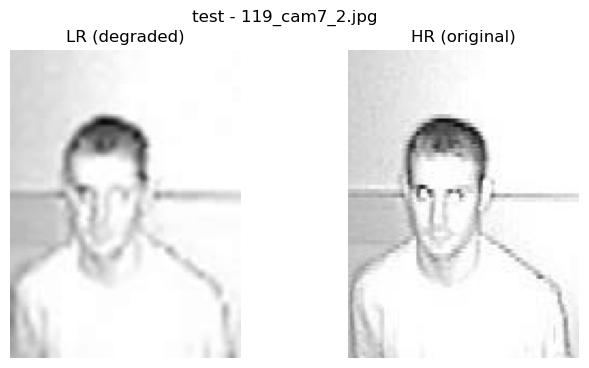

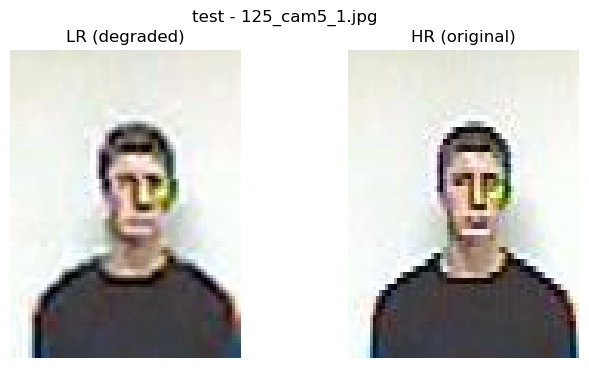

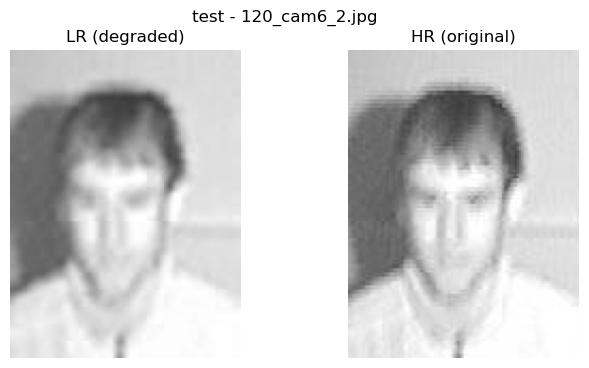

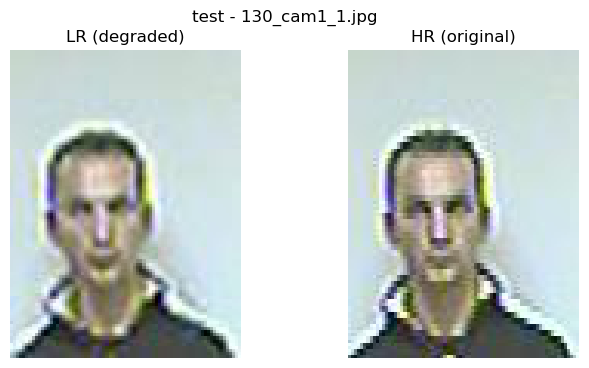

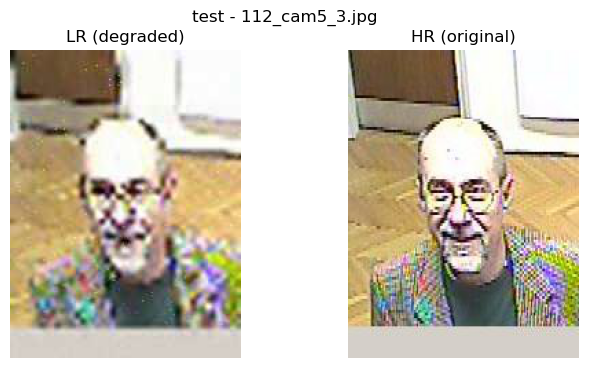

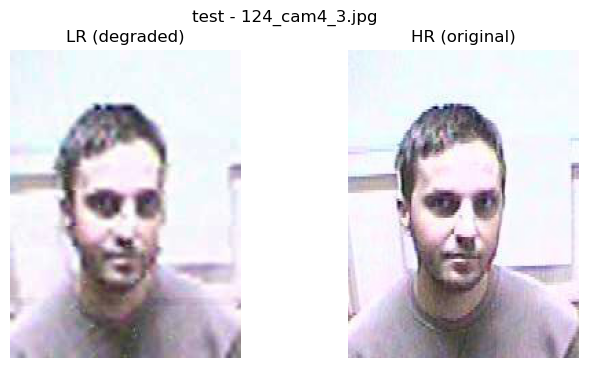

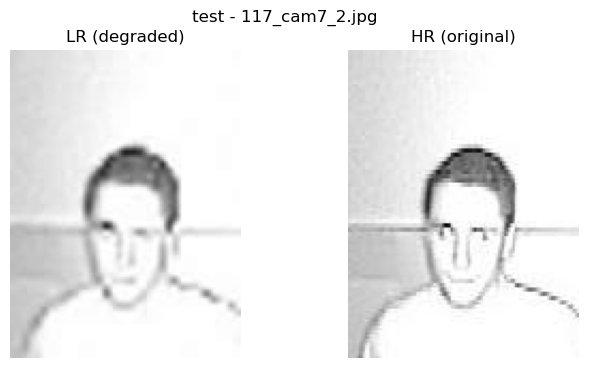

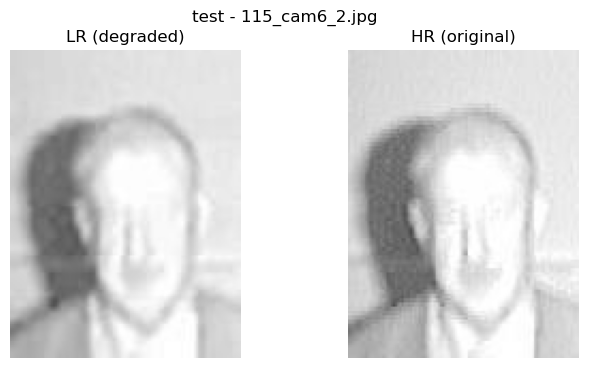

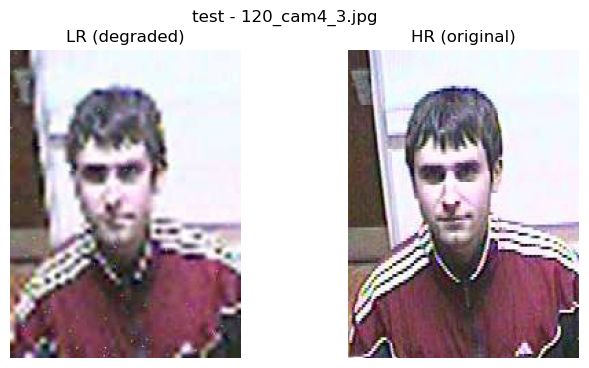

In [53]:
# import os
# from PIL import Image
# import matplotlib.pyplot as plt
# import random

# output_path = r"D:\Face_Detection\SWINIR_dataset"  # minimal degradation
# splits = ['train', 'val', 'test']
# num_samples = 12  # number of pairs to show per split

# for split in splits:
#     hr_folder = os.path.join(output_path, split, 'HR')
#     lr_folder = os.path.join(output_path, split, 'LR')

#     # Randomly pick a few images
#     hr_files = os.listdir(hr_folder)
#     sample_files = random.sample(hr_files, min(num_samples, len(hr_files)))

#     print(f"\n=== {split.upper()} ===")
#     for f in sample_files:
#         hr_img = Image.open(os.path.join(hr_folder, f))
#         lr_img = Image.open(os.path.join(lr_folder, f))

#         # Display side by side
#         plt.figure(figsize=(8,4))
#         plt.suptitle(f"{split} - {f}", fontsize=12)

#         plt.subplot(1,2,1)
#         plt.imshow(lr_img)
#         plt.title("LR (degraded)")
#         plt.axis('off')

#         plt.subplot(1,2,2)
#         plt.imshow(hr_img)
#         plt.title("HR (original)")
#         plt.axis('off')

#         plt.show()

# Added rescalling

In [7]:
import os
from PIL import Image
import numpy as np
import cv2
import random

split_folders = ['train', 'val', 'test']
input_path = r"D:\Face_Detection\prepared_dataset"
output_path = r"D:\Face_Detection\prepared_dataset_128"  # New output path

# Configuration
HR_SIZE = 128  # HR images will be 96x96
LR_SIZE = 64  # LR images will be 48x48 (2x downscale)
SCALE = 2

# Make folders
for split in split_folders:
    os.makedirs(os.path.join(output_path, split, 'HR'), exist_ok=True)
    os.makedirs(os.path.join(output_path, split, 'LR'), exist_ok=True)

print("Created output directories")

# Function to assign strength based on filename
def get_strength_from_filename(filename):
    if '_cam8.jpg' in filename:
        return 1.5
    elif filename.endswith('_1.jpg'):
        return 0.2
    elif filename.endswith('_2.jpg'):
        return 0.5
    elif filename.endswith('_3.jpg'):
        return 0.9
    else:
        return random.uniform(0.15, 0.65)

# Scanline shift effect
def add_scanline_shift(img, strength):
    """Shifts horizontal rows randomly left/right with brightness changes"""
    if strength < 0.05:
        return img
    
    h, w = img.shape[:2]
    result = img.copy()
    
    num_bands = int(2 + strength * 4)
    spacing = h // (num_bands + 1)
    
    for i in range(num_bands):
        base_position = spacing * (i + 1)
        random_offset = random.randint(-spacing // 3, spacing // 3)
        start_row = max(0, min(base_position + random_offset, h - 6))
        
        band_height = random.randint(6, 24)
        end_row = min(start_row + band_height, h)
        
        max_shift = int(1 + strength * 2)
        shift = random.randint(-max_shift, max_shift)
        
        if abs(shift) < 1:
            continue
        
        band = result[start_row:end_row, :].copy()
        
        if shift > 0:
            band[:, shift:] = band[:, :-shift]
            band[:, :shift] = band[:, shift:shift+1]
        elif shift < 0:
            band[:, :shift] = band[:, -shift:]
            band[:, shift:shift+1] = band[:, shift-1:shift]
        
        brightness_change = random.uniform(-12 * strength, 12 * strength)
        band = np.clip(band.astype(np.float32) + brightness_change, 0, 255).astype(np.uint8)
        
        result[start_row:end_row, :] = band
    
    return result

# Degradation function
def degrade_image_for_sr(img, strength, target_lr_size):
    """Degrade image with actual 2x downscaling for super-resolution"""
    img = np.array(img).astype(np.float32)
    h, w = img.shape[:2]
    
    # Gaussian blur
    kernel_size = 1 + int(2 * strength)
    if kernel_size % 2 == 0:
        kernel_size += 1
    degraded = cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)
    
    # Gaussian noise
    sigma = 4 * strength
    noise = np.random.normal(0, sigma, degraded.shape)
    degraded = degraded + noise
    
    # Rainbow noise
    degraded_uint8 = np.clip(degraded, 0, 255).astype(np.uint8)
    rainbow_strength = 0.4 * strength
    rainbow_noise = np.random.normal(0, rainbow_strength, degraded.shape).astype(np.uint8)
    degraded = cv2.add(degraded_uint8, rainbow_noise)
    
    # Scanline shift
    degraded = add_scanline_shift(degraded, strength * 0.8)
    
    # JPEG compression
    jpeg_quality = int(85 - (40 * strength))
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), jpeg_quality]
    _, encimg = cv2.imencode('.jpg', degraded, encode_param)
    degraded = cv2.imdecode(encimg, cv2.IMREAD_COLOR)
    
    # Downscale to LR size
    lr = cv2.resize(degraded, (target_lr_size, target_lr_size), interpolation=cv2.INTER_CUBIC)
    
    return lr

# SMART CROPPING FUNCTION
def smart_crop(img, target_size, is_train=True):
    """
    Smart cropping that handles images smaller than target size
    - If both dimensions >= target_size: crop
    - If one dimension < target_size: resize shorter dimension to target, then crop
    - Preserves aspect ratio as much as possible
    """
    w, h = img.size
    min_dim = min(w, h)
    
    # Case 1: Both dimensions are >= target_size (ideal case)
    if w >= target_size and h >= target_size:
        if is_train:
            # Random crop for training
            left = random.randint(0, w - target_size)
            top = random.randint(0, h - target_size)
        else:
            # Center crop for val/test
            left = (w - target_size) // 2
            top = (h - target_size) // 2
        
        return img.crop((left, top, left + target_size, top + target_size))
    
    # Case 2: One or both dimensions < target_size
    # Strategy: Resize so that min_dim = target_size, then crop the other dimension
    
    if min_dim < target_size:
        # Calculate new dimensions
        if w < h:
            # Width is smaller - make width = target_size
            new_w = target_size
            new_h = int(h * (target_size / w))
        else:
            # Height is smaller - make height = target_size
            new_h = target_size
            new_w = int(w * (target_size / h))
        
        # Resize with high-quality interpolation
        img = img.resize((new_w, new_h), Image.LANCZOS)
        w, h = new_w, new_h
    
    # Now both dimensions should be >= target_size
    # Do final crop
    if is_train:
        left = random.randint(0, w - target_size) if w > target_size else 0
        top = random.randint(0, h - target_size) if h > target_size else 0
    else:
        left = (w - target_size) // 2 if w > target_size else 0
        top = (h - target_size) // 2 if h > target_size else 0
    
    return img.crop((left, top, left + target_size, top + target_size))

# Process each split
print("\n" + "="*60)
print("STARTING SMART DATASET PREPARATION")
print("="*60)

total_stats = {'processed': 0, 'resized': 0, 'cropped': 0}

for split in split_folders:
    print(f"\n{'='*60}")
    print(f"Processing {split.upper()} split")
    print(f"{'='*60}")
    
    input_split = os.path.join(input_path, split)
    hr_folder = os.path.join(output_path, split, 'HR')
    lr_folder = os.path.join(output_path, split, 'LR')
    
    if not os.path.exists(input_split):
        print(f"❌ ERROR: Directory not found: {input_split}")
        continue
    
    files = [f for f in os.listdir(input_split) if f.endswith(('.jpg', '.png', '.jpeg'))]
    print(f"Found {len(files)} images in {split}")
    
    count = 0
    resized_count = 0
    errors = 0
    
    for f in files:
        try:
            # Open original image
            img_path = os.path.join(input_split, f)
            img = Image.open(img_path).convert('RGB')
            
            w, h = img.size
            min_dim = min(w, h)
            
            # Track if we needed to resize
            needed_resize = min_dim < HR_SIZE
            if needed_resize:
                resized_count += 1
            
            # Smart crop to get HR image
            hr_img = smart_crop(img, HR_SIZE, is_train=(split == 'train'))
            
            # Verify output size
            assert hr_img.size == (HR_SIZE, HR_SIZE), f"HR size mismatch: {hr_img.size}"
            
            # Save HR image
            hr_img.save(os.path.join(hr_folder, f), quality=95)
            
            # Determine degradation strength
            strength = get_strength_from_filename(f)
            
            # Generate LR image with degradation + 2x downscaling
            lr_img = degrade_image_for_sr(hr_img, strength, LR_SIZE)
            lr_img = Image.fromarray(lr_img)
            
            # Verify LR size
            assert lr_img.size == (LR_SIZE, LR_SIZE), f"LR size mismatch: {lr_img.size}"
            
            # Save LR image
            lr_img.save(os.path.join(lr_folder, f), quality=95)
            
            count += 1
            if count % 100 == 0:
                print(f"  Processed: {count}/{len(files)} | Resized: {resized_count} | Errors: {errors}")
        
        except Exception as e:
            print(f"  ❌ Error processing {f}: {e}")
            errors += 1
    
    print(f"\n{split.upper()} Summary:")
    print(f"  ✓ Processed: {count}/{len(files)} images ({count/len(files)*100:.1f}%)")
    print(f"  ↗ Resized (small images): {resized_count} ({resized_count/count*100:.1f}%)")
    print(f"  ✂ Pure crops: {count - resized_count} ({(count-resized_count)/count*100:.1f}%)")
    print(f"  ❌ Errors: {errors}")
    
    total_stats['processed'] += count
    total_stats['resized'] += resized_count
    total_stats['cropped'] += (count - resized_count)

print("\n" + "="*60)
print("DATASET PREPARATION COMPLETE!")
print("="*60)
print(f"Total processed: {total_stats['processed']} images")
print(f"  - Pure crops (both dims ≥96): {total_stats['cropped']} ({total_stats['cropped']/total_stats['processed']*100:.1f}%)")
print(f"  - Resized + cropped (min dim <96): {total_stats['resized']} ({total_stats['resized']/total_stats['processed']*100:.1f}%)")
print()
print(f"HR size: {HR_SIZE}x{HR_SIZE}")
print(f"LR size: {LR_SIZE}x{LR_SIZE}")
print(f"Scale factor: {SCALE}x")
print(f"Output directory: {output_path}")
print()
print("Strategy used:")
print("  • Images with both dims ≥96: Random/center crop")
print("  • Images with min dim <96: Resize shorter dimension to 96, then crop")
print("  • Result: All images preserved, minimal distortion")
print("="*60)

Created output directories

STARTING SMART DATASET PREPARATION

Processing TRAIN split
Found 1980 images in train
  Processed: 100/1980 | Resized: 64 | Errors: 0
  Processed: 200/1980 | Resized: 128 | Errors: 0
  Processed: 300/1980 | Resized: 192 | Errors: 0
  Processed: 400/1980 | Resized: 255 | Errors: 0
  Processed: 500/1980 | Resized: 319 | Errors: 0
  Processed: 600/1980 | Resized: 382 | Errors: 0
  Processed: 700/1980 | Resized: 446 | Errors: 0
  Processed: 800/1980 | Resized: 510 | Errors: 0
  Processed: 900/1980 | Resized: 574 | Errors: 0
  Processed: 1000/1980 | Resized: 637 | Errors: 0
  Processed: 1100/1980 | Resized: 700 | Errors: 0
  Processed: 1200/1980 | Resized: 764 | Errors: 0
  Processed: 1300/1980 | Resized: 828 | Errors: 0
  Processed: 1400/1980 | Resized: 892 | Errors: 0
  Processed: 1500/1980 | Resized: 955 | Errors: 0
  Processed: 1600/1980 | Resized: 1019 | Errors: 0
  Processed: 1700/1980 | Resized: 1082 | Errors: 0
  Processed: 1800/1980 | Resized: 1146 | Err